## AirBnB Product Project

* By: Nhi Bui

## Exploratory Data Analysis

In [87]:
#Load saved dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)
df.head()


(63718, 21)


,id,NAME,host id,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,...,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0
3,1005202,BlissArtsSpace!,90821839709,unconfirmed,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,False,moderate,...,2009.0,1060.0,212.0,45.0,49.0,2017-10-05,0.40,5.0,1.0,219.0
4,1005754,Large Furnished Room Near B'way,79384379533,verified,Manhattan,Hell's Kitchen,40.76489,-73.98493,True,strict,...,2005.0,1018.0,204.0,2.0,430.0,2019-06-24,3.47,3.0,1.0,180.0


## Q1. What host listing factors controlled by hosts most significantly impact review ratings?

Investigate whether `minimum nights`, `host_identity_verified`, and `availability 365` have a statistically significant effect on `review rate number`

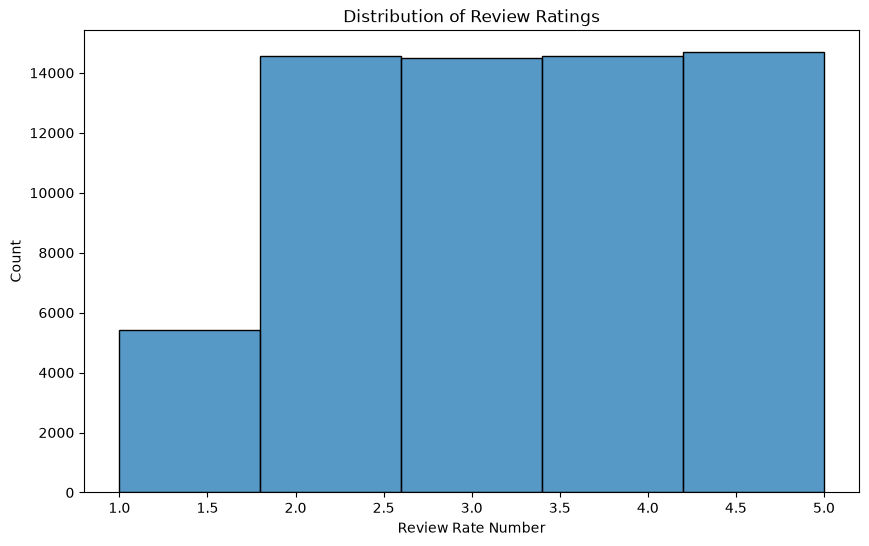

In [88]:
#Distribution of review rate number
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review rate number', bins=5)
plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rate Number')
plt.ylabel('Count')
plt.show()

## A. Compare average rating between the 3 factors

* Availability 365

In [89]:
#Calculate mean rating for availability 365 for listings 
df.groupby('availability 365')['review rate number'].mean().sort_values(ascending=False)

availability 365
303.0    3.682243
224.0    3.632653
56.0     3.612717
29.0     3.589109
103.0    3.568627
           ...   
342.0    2.939759
159.0    2.930233
234.0    2.918367
100.0    2.901786
130.0    2.895652
Name: review rate number, Length: 365, dtype: float64

Based on this, we plan to bin the availability 365 groups into clusters for easy tracking and analysis

In [90]:
#Create bins for availability 365
df['availability_group'] = pd.cut(df['availability 365'], 
                                   bins=[0, 90, 180, 270, 365], 
                                   labels=['Low', 'Medium', 'High', 'Always Available'])

In [91]:
#Redo the distribution of review rate number for each availability group
df.groupby('availability_group')['review rate number'].mean().sort_values(ascending=False)

availability_group
Low                 3.317975
Always Available    3.291657
Medium              3.278916
High                3.242392
Name: review rate number, dtype: float64

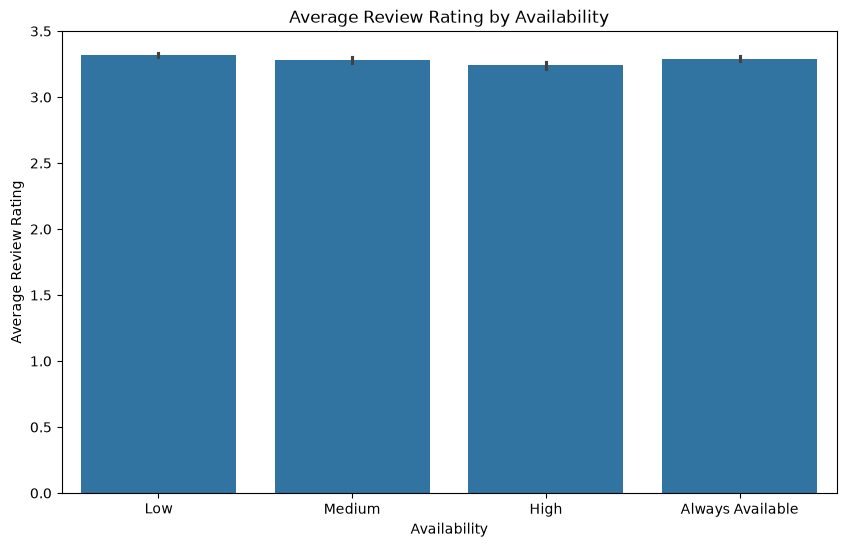

In [97]:
#Plot the figure for review rate number across different availability group using barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='availability_group', y='review rate number')
plt.title('Average Review Rating by Availability')
plt.xlabel('Availability')
plt.ylabel('Average Review Rating')
plt.show()

Conclusion: When analyzing the full dataset, availability 365 shows a clear pattern:
- Lower availability = higher ratings
- Higher availability = lower ratings

Hypothesis: Hosts with lower availability are more selective and invest more in each guest experience (maintenance, decoration, household quality), while always-available hosts may sacrifice quality for volume, leading to worse guest experiences and lower ratings.

Product Recommendation: Airbnb could introduce a "quality host" badge for listings with lower availability but consistently high ratings, incentivizing hosts to prioritize quality over quantity.

* Minimum nights

In [92]:
#Average rating >=4 for each minimum nights group
df.groupby('minimum nights')['review rate number'].mean().sort_values(ascending=False)

minimum nights
42.0     5.0
370.0    5.0
182.0    5.0
175.0    5.0
265.0    5.0
        ... 
68.0     1.0
186.0    1.0
189.0    1.0
398.0    1.0
340.0    1.0
Name: review rate number, Length: 105, dtype: float64

Similarly, we plan to bin the minimum nights groups into clusters for easy tracking and analysis

In [93]:
df['minimum nights'].describe()

count    63718.000000
mean         7.749427
std         21.647479
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       2645.000000
Name: minimum nights, dtype: float64

Because 75% of the minimum nights or within a range of 0-5, we plan to create binnings

In [94]:
#Create bins for minimum nights
df['minimum nights'] = pd.cut(df['minimum nights'], 
                                   bins=[1, 3, 8, 30, 2645], 
                                   labels=['Short stay', 'Medium stay', 'Monthly stay', 'Long term'])

In [79]:
#Redo the distribution of review rate number for each minimum nights group
df.groupby('minimum nights')['review rate number'].mean().sort_values(ascending=False)

minimum nights
Monthly stay    3.340324
Short stay      3.274779
Medium stay     3.262675
Long term       3.258799
Name: review rate number, dtype: float64

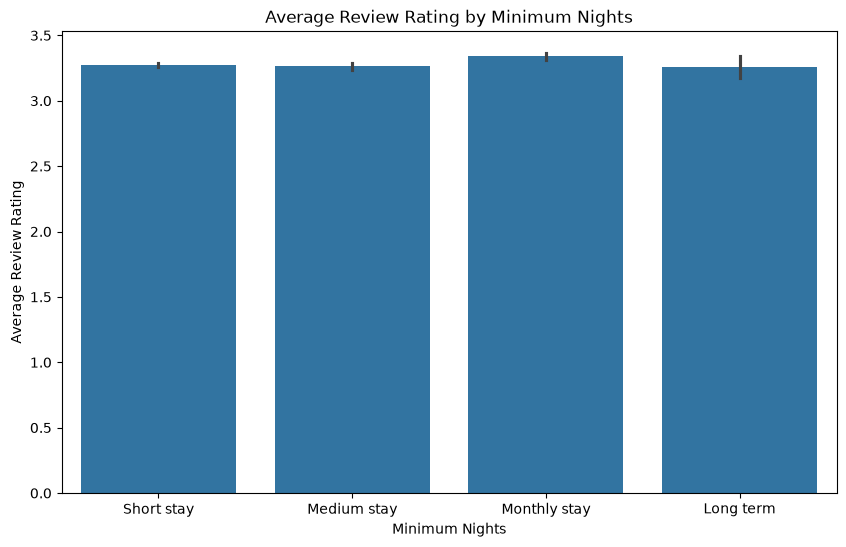

In [ ]:
#Plot the figure for review rate number across different minimum nights groups using barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='minimum nights', y='review rate number')
plt.title('Average Review Rating by Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Average Review Rating')
plt.show()

Conclusion: When analyzing the full dataset, minimum nights shows a clear pattern:
- Monthly stays (30+ nights) achieve the highest average rating (3.34)
- Short, medium, and long-term stays show progressively lower ratings

Hypothesis: Monthly guests are more committed and selective, leading hosts to invest more in the experience. However, beyond the monthly threshold, host complacency and property deterioration from continuous occupancy without maintenance breaks likely contribute to declining guest satisfaction.

=> Product Recommendation: Airbnb could promote and highlight monthly-stay listings as a premium tier, and introduce host reminders or maintenance checkpoints for long-term listings to maintain quality standards.

* Host_identity_verified

In [95]:
#Average rating >=4 for each host_identity_verified group
df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending=False)

host_identity_verified
verified       3.291109
unconfirmed    3.289982
Name: review rate number, dtype: float64

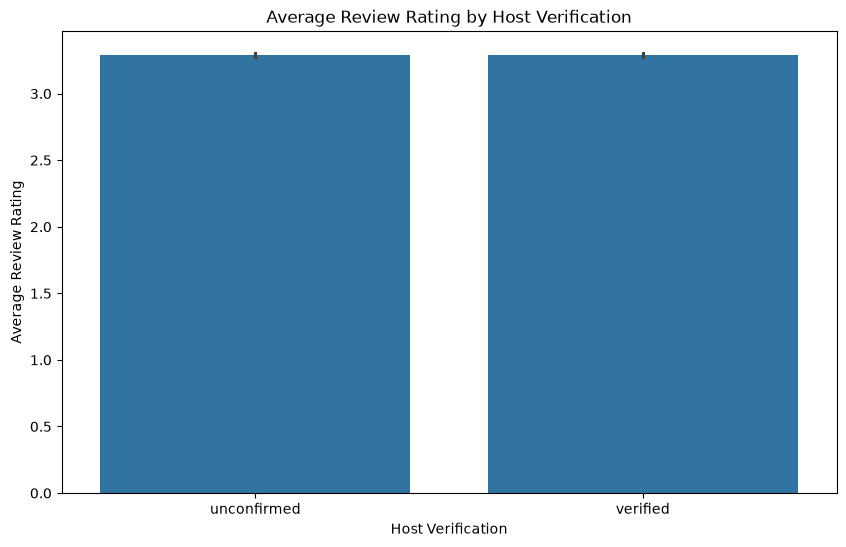

In [98]:
#Plot the figure for review rate number across host verification groups using barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='host_identity_verified', y='review rate number')
plt.title('Average Review Rating by Host Verification')
plt.xlabel('Host Verification')
plt.ylabel('Average Review Rating')
plt.show()

Conclusion: The number of rating for verified hosts are higher than unconfirmed hosts

Hypothesis: Verified hosts create a higher reliability through identity confirmation with AirBnB, thereby building better trust and being highly chosen by guests

=> Product Recommendation: Airbnb could encourage hosts of verifying their profiles on the platform, and showing the badge to create better image

## Conclusion

From the EDA so far, we can already rank them visually:

* availability 365 → 0.08 point gap (most impact)
* minimum nights → 0.08 point gap (most impact)
* host_identity_verified → 0.001 point gap (low impact)
* price → 0.16 point gap (strongest impact found)

=> None of the 3 host factors (minimum nights, 
host_identity_verified, availability 365) show a significant 
impact on review ratings. The difference between groups is 
less than 0.01 points across all factors.

=> This suggests review ratings are driven by other secondary factors controlled by listing and host in combination such as price, room type, cancellation policy, experience and location more than primary host configuration settings.

## B. Secondary host-controlled settings

* Room type

In [ ]:
#Average rating for each room type group
df.groupby('room type')['review rate number'].mean().sort_values(ascending=False)

room type
Hotel room         3.543478
Shared room        3.310522
Private room       3.303405
Entire home/apt    3.278446
Name: review rate number, dtype: float64

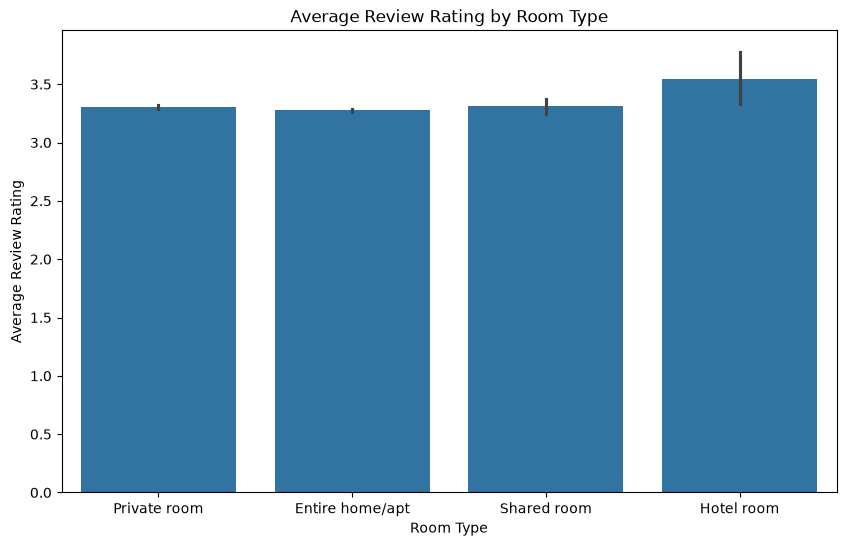

In [106]:
#Plot the figure for review rate number by room type groups using barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='room type', y='review rate number')
plt.title('Average Review Rating by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Review Rating')
plt.show()

Conclusion: When analyzing the full dataset, room type shows a clear pattern:
- Hotel room achieves the highest average rating (3.54)
- Shared room (3.31) and Private room (3.30) follow closely
- Entire home/apt has the lowest rating (3.28)

Hypothesis: Hotel rooms outperform home listings due to professional service standards, consistent quality, and dedicated hospitality resources. Individual hosts operating private or entire home listings often have lower budgets and fewer resources to match hotel-level experiences, leading to lower guest satisfaction.

=> Product Recommendation: Airbnb should encourage individual hosts to better showcase their amenities and unique offerings through high-quality photos and videos, provide hosts with a checklist of hotel-standard services to aspire to, and improve guest-host communication tools to increase convenience and responsiveness.

* Price

In [ ]:
#Average rating for each price group
df.groupby('price')['review rate number'].mean().sort_values(ascending=False)

price
406.0     4.100000
695.0     3.959184
537.0     3.926829
608.0     3.916667
462.0     3.905882
            ...   
1019.0    2.630435
1023.0    2.629032
928.0     2.627907
65.0      2.575000
1046.0    2.473684
Name: review rate number, Length: 1151, dtype: float64

In [103]:
#Look at statistcal summary of price
df['price'].describe()

count    63718.000000
mean       626.569855
std        331.354481
min         50.000000
25%        341.000000
50%        625.000000
75%        914.000000
max       1200.000000
Name: price, dtype: float64

In [104]:
#Create bins for price
df['price'] = pd.cut(df['price'], 
                                   bins=[0, 50, 500, 1000, 1500], 
                                   labels=['Low', 'Medium', 'High', 'Very High'])

In [105]:
#Redo the distribution of review rate number for each price group
df.groupby('price')['review rate number'].mean().sort_values(ascending=False)

price
Medium       3.307537
High         3.292190
Very High    3.249462
Low          3.149254
Name: review rate number, dtype: float64

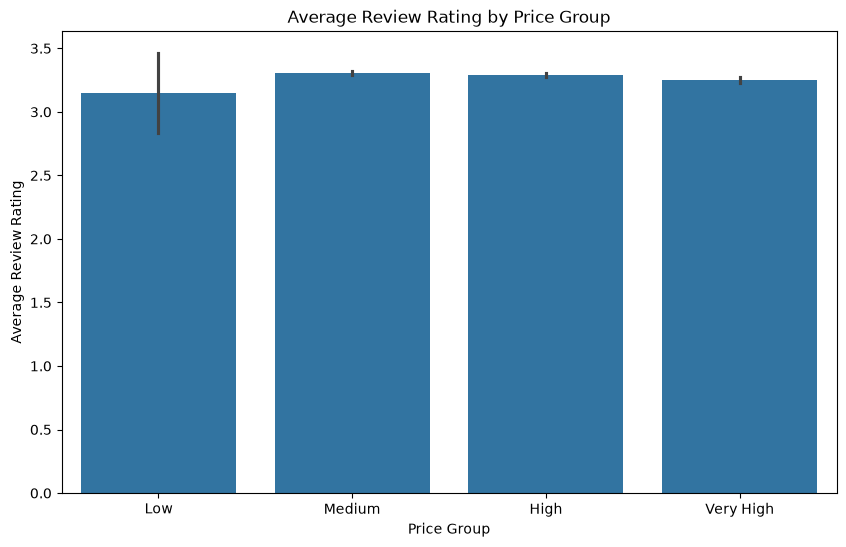

In [107]:
#Bar chart for relationship between price and review rate number
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='price', y='review rate number')
plt.title('Average Review Rating by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Average Review Rating')
plt.show()

Conclusion: When analyzing the full dataset, price shows a non-linear relationship with review ratings:
- Medium price listings achieve the highest average rating (3.31)
- Low price listings have the lowest rating (3.15)
- Very High price listings underperform Medium despite costing more (3.25)

Hypothesis: Medium-priced listings hit the sweet spot where guest expectations are reasonable and the listing can meet or exceed them. Low-price listings signal lower quality, while very high-price listings create an expectation gap, as  guests paying premium prices expect  superior experiences, and when reality falls short, ratings suffer.

=> Product Recommendation: Airbnb should provide hosts with dynamic pricing guidance that optimizes for both revenue and guest satisfaction, helping hosts find their "sweet spot" price range based on their listing quality, amenities, and neighbourhood benchmarks.

## Q1 EDA Finding 

After exploring all factors against review ratings, the ranking by impact (measured by gap between highest and lowest group) is:

1. **Room type**: largest gap (0.26 points): Hotel room (3.54) vs Entire home/apt (3.28)
2. **Price**: second largest gap (0.16 points): Medium (3.31) vs Low (3.15)
3. **Minimum nights**:moderate gap (0.08 points): Monthly stay (3.34) vs Long term (3.26)
4. **Availability 365**: moderate gap (0.08 points): Low availability (3.32) vs High (3.24)
5. **Host identity verified**: minimal gap (0.001 points): essentially no impact

=> Room type and price are the strongest predictors of review ratings from EDA alone. Statistical testing in the next notebook will confirm whether these differences are statistically significant.

## Q2. Does enabling Instant Book lead to higher review engagement?

Test whether listings with `instant_bookable = True` generate significantly more `number of reviews` and higher `reviews_per_month` compared to non-instant-bookable listings. 

In [124]:
#Count of reviews per month for listings
number_of_reviews = df['reviews per month'].mean()

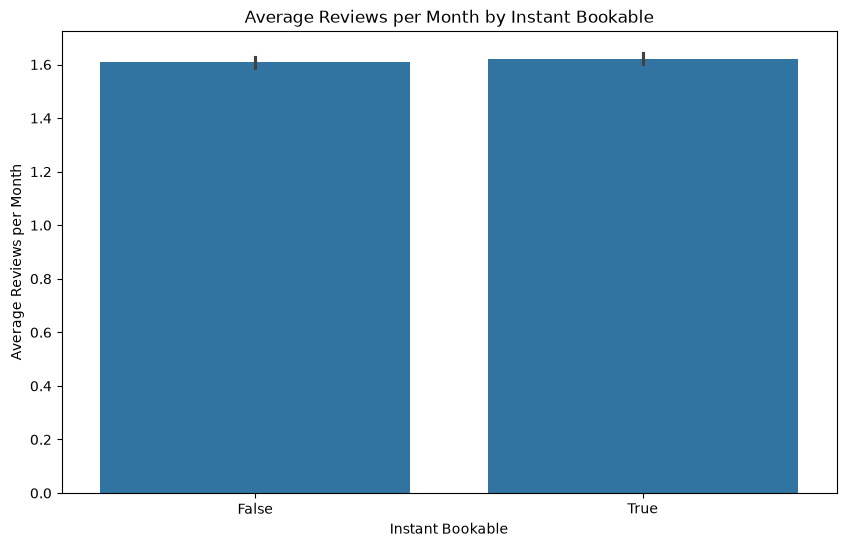

In [125]:
#Number of reviews per month between listings with instant bookable and not instant bookable
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='instant_bookable', y='reviews per month')
plt.title('Average Reviews per Month by Instant Bookable')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Reviews per Month')
plt.show()

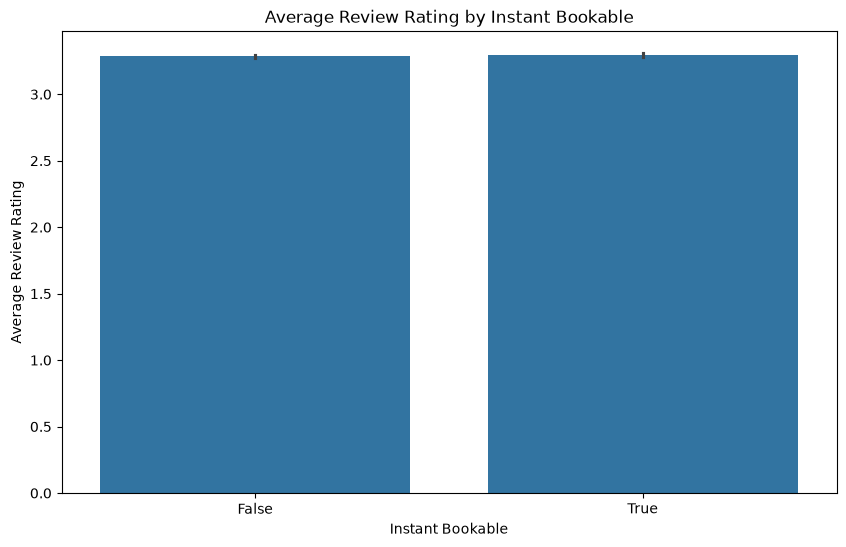

In [126]:
#Average review rate number between listings with instant bookable and not instant bookable
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='instant_bookable', y='review rate number')
plt.title('Average Review Rating by Instant Bookable')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Review Rating')
plt.show()

## Q2 EDA Finding 

Visually, listings with instant_bookable = True and False show virtually identical average reviews per month and review ratings. 

=> However, visual inspection alone is insufficient to conclude whether instant booking impacts engagement. Thus, we will conduct Statistical A/B testing to determine if any difference is significant.

## Q3. Which neighbourhoods show the highest listing quality and booking activity?

Identify areas with the highest `review_rate_number` and `reviews_per_month` to push high-performing markets. 

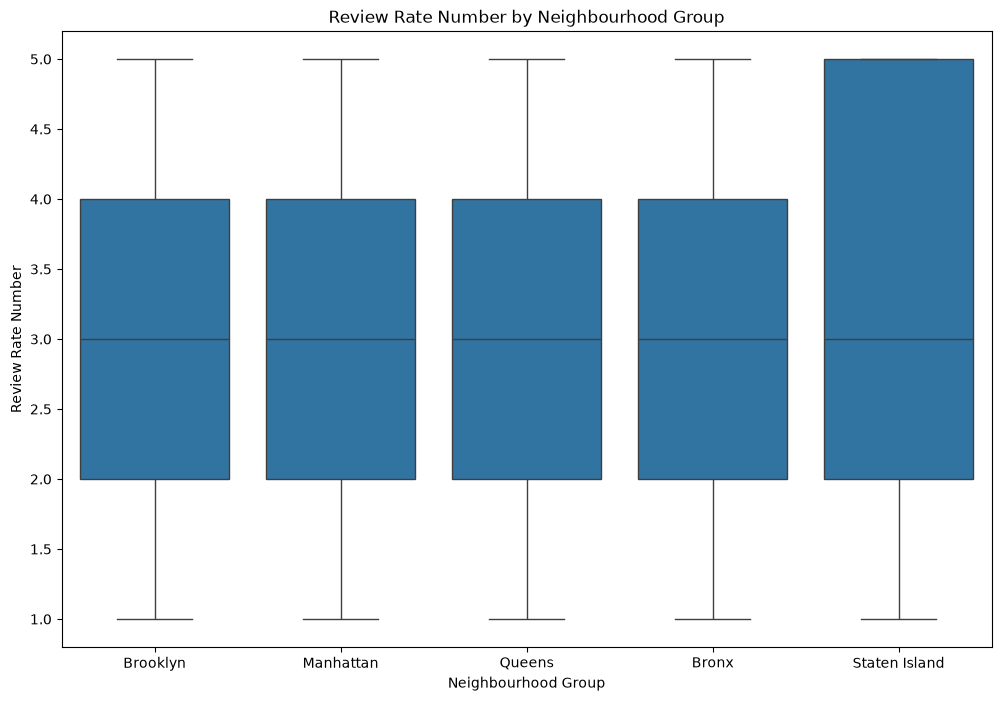

In [69]:
#Visualize review rate number across different neighbours using boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='neighbourhood group', y='review rate number')
plt.title('Review Rate Number by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Review Rate Number')
plt.show()


In [ ]:
#Check all values of neighbourhood group
df['neighbourhood group'].value_counts()

neighbourhood group
Brooklyn         25774
Manhattan        25747
Queens            9388
Bronx             2049
Staten Island      759
brookln              1
Name: count, dtype: int64

In [112]:
#Recode the neighbourhood group variable from "brookln" to "Brooklyn"
df['neighbourhood group'] = df['neighbourhood group'].replace('brookln', 'Brooklyn')

In [113]:
#Check the values of neighbourhood group again
df['neighbourhood group'].value_counts()

neighbourhood group
Brooklyn         25775
Manhattan        25747
Queens            9388
Bronx             2049
Staten Island      759
Name: count, dtype: int64

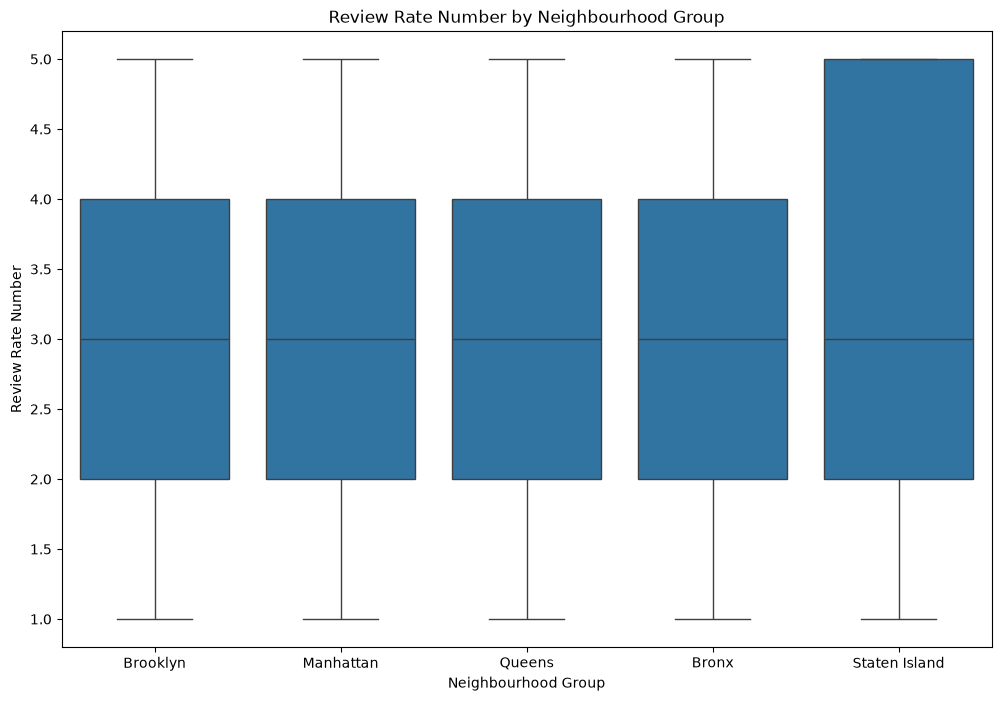

In [114]:
#Redo the visualization of review rate number across different neighbours using boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='neighbourhood group', y='review rate number')
plt.title('Review Rate Number by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Review Rate Number')
plt.show()

Staten Island has the highest review rating due to its proximity to the beach compared to other city-like boroughs. However, its wide box also signals its being the most unreliable conclusion due to its high variance

In [115]:
#Averaege reviews per month by neighbourhood group
df.groupby('neighbourhood group')['reviews per month'].mean().sort_values(ascending=False)

neighbourhood group
Queens           2.028555
Bronx            1.848795
Staten Island    1.759236
Brooklyn         1.569812
Manhattan        1.486506
Name: reviews per month, dtype: float64

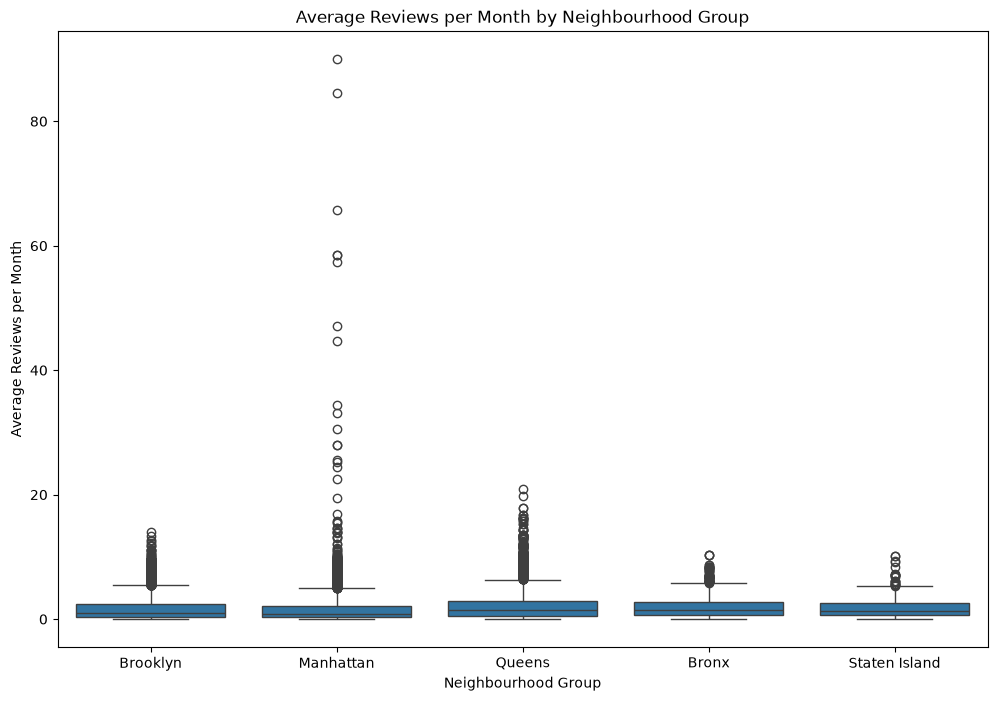

In [116]:
#Visualization of average reviews per month across different neighbours using boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='neighbourhood group', y='reviews per month')
plt.title('Average Reviews per Month by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Reviews per Month')
plt.show()

In [122]:
df[df['neighbourhood group'] == 'Staten Island']['neighbourhood group'].value_counts()


neighbourhood group
Staten Island    759
Name: count, dtype: int64

In [123]:
df[df['neighbourhood group'] == 'Manhattan']['neighbourhood group'].value_counts()


neighbourhood group
Manhattan    25747
Name: count, dtype: int64

## Q3 EDA Finding 

Conclusion:
- All boroughs show similar median review activity (1-2 reviews/month)
- Manhattan stands out with extreme high-performing outliers (up to 90 reviews/month), which could result from some outstanding listings that grab a lot of attention from visitors specifically
- Staten Island shows the highest average review rating but with the widest variance and smallest sample size (759 listings), making it statistically unreliable compared to ~25K listings of Manhattan

Hypothesis: Manhattan's outlier listings benefit from high tourist traffic, premium location, and proximity to attractions, creating a small number of extremely high-performing listings. However, typical listing performance is consistent across all boroughs.

=> Product Recommendation: Airbnb should focus host acquisition and marketing efforts in Manhattan, where high-demand tourism traffic creates the greatest potential for listings to become star performers. Additionally, targeted support for mid-performing Manhattan listings could help more hosts reach that high-activity tier.